# Superstore Exploratory Data Analysis (EDA)
This notebook provides a comprehensive EDA on the Sample Superstore dataset. It covers data cleaning, feature engineering, and visualizations to uncover insights regarding sales, profitability, and regional performance.

### 1. Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set visual styles
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

### 2. Loading and Inspecting the Data

In [6]:
df = pd.read_csv("samplesuperstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [8]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


### 3. Data Cleaning & Feature Engineering
Here we will check for missing values, handle duplicates, convert date columns to proper datetime objects, and calculate delivery times.

In [9]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Check and drop duplicates
duplicate_count = df.duplicated().sum()
print(f"\nFound {duplicate_count} duplicate rows. Dropping duplicates...")
df.drop_duplicates(inplace=True)

Missing Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

Found 0 duplicate rows. Dropping duplicates...


In [10]:
# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Feature Engineering: Delivery Days
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df[['Order Date', 'Ship Date', 'Delivery Days']].head()

,Order Date,Ship Date,Delivery Days
0,2023-01-03,2023-01-07,4
1,2023-01-04,2023-01-08,4
2,2023-01-04,2023-01-08,4
3,2023-01-04,2023-01-08,4
4,2023-01-05,2023-01-12,7


### 4. Data Visualization & Insights

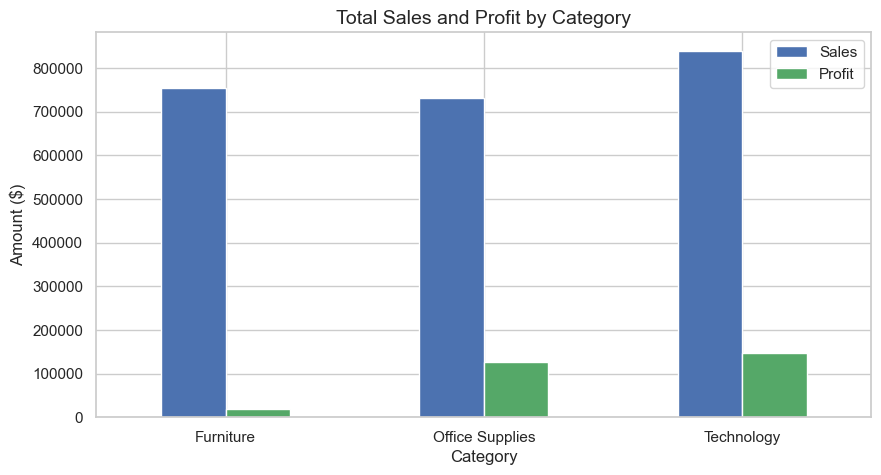

In [11]:
# Sales and Profit by Category
category_agg = df.groupby('Category')[['Sales', 'Profit']].sum()

category_agg.plot(kind='bar', figsize=(10, 5), color=['#4C72B0', '#55A868'])
plt.title("Total Sales and Profit by Category", fontsize=14)
plt.ylabel("Amount ($)")
plt.xticks(rotation=0)
plt.show()

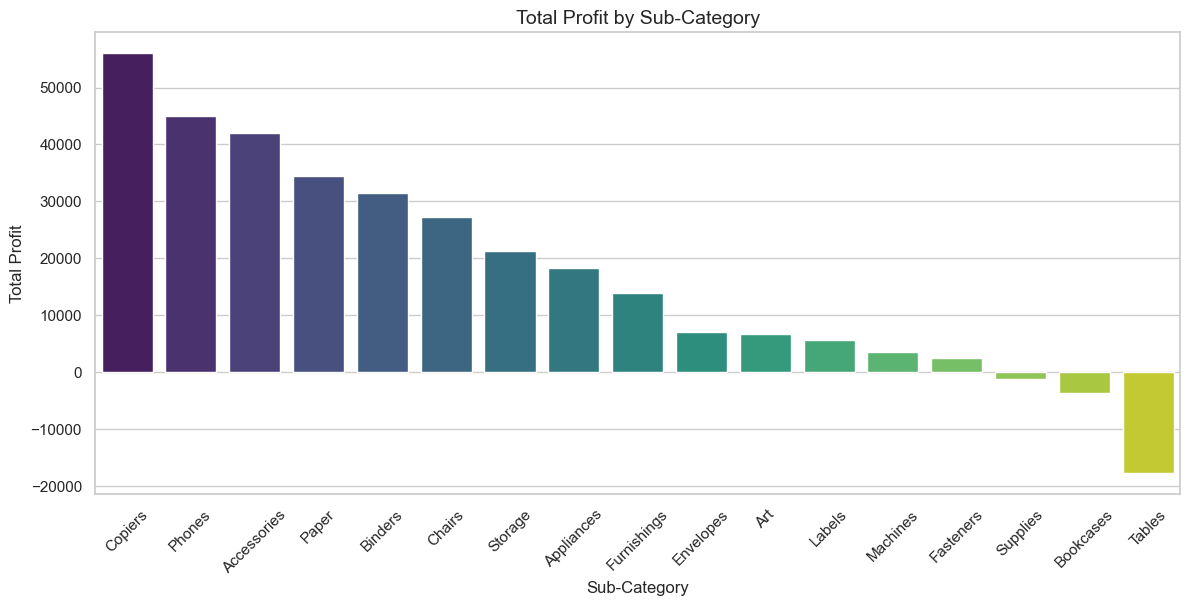

In [12]:
# Profit by Sub-Category
plt.figure(figsize=(14, 6))
sub_cat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=sub_cat_profit.index, y=sub_cat_profit.values, palette='viridis')
plt.title("Total Profit by Sub-Category", fontsize=14)
plt.ylabel("Total Profit")
plt.xlabel("Sub-Category")
plt.xticks(rotation=45)
plt.show()

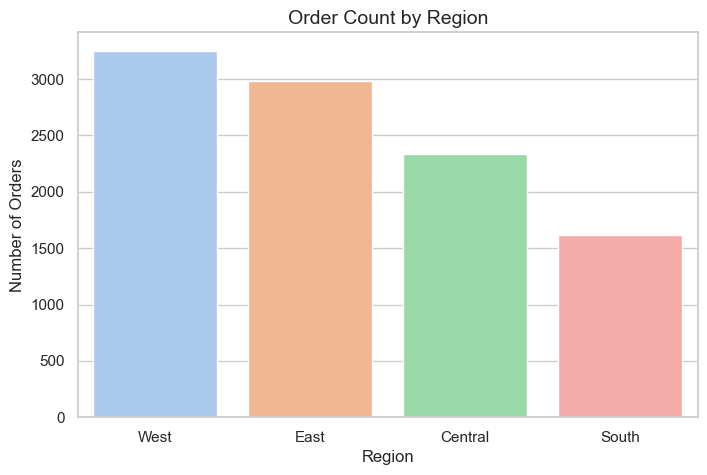

In [13]:
# Region-wise Sales Performance
plt.figure(figsize=(8, 5))
sns.countplot(x='Region', data=df, order=df['Region'].value_counts().index, palette='pastel')
plt.title('Order Count by Region', fontsize=14)
plt.ylabel('Number of Orders')
plt.show()

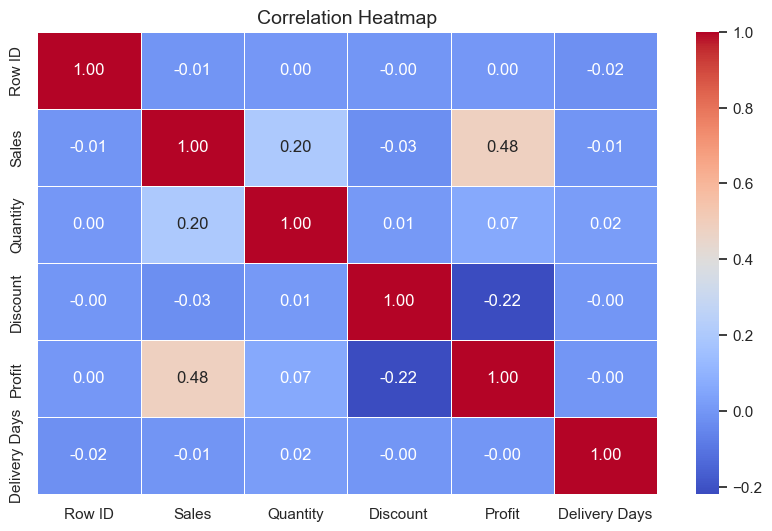

In [14]:
# Correlation Matrix (Numeric variables only)
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

### Key Takeaways:
* **Category Performance:** Technology drives the highest profit, while Furniture yields minimal profit despite high sales.
* **Sub-Category Outliers:** Copiers and Phones are highly profitable. Tables and Bookcases operate at a significant loss.
* **Discount Impact:** The correlation matrix shows a distinct negative correlation between discounts and profit.